In [1]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [17]:
colors = sns.color_palette()
colors

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

# Results for PPO, PD Control and Baseline

In [2]:
mean = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
std = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
ra = [10000, 100000, 1000000, 5000000]


# read from csv
for method in ["baseline", "pd", "ppo", "ppo_ra10000", "ppo_ra100000"]:
    for r in ra:
        path = f"res/{method}_ra{r}.csv"
        try:
            df = pandas.read_csv(path)

            # mean per episode
            df = df.groupby('episode').mean()

            mean[method].append(df["nusselt"].mean())
            std[method].append(df["nusselt"].std())
        except Exception as e:
            mean[method].append(0)
            std[method].append(0)

# compute percentage
mean_percent = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
std_percent = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
for idx in range(len(mean["baseline"])):
    for method in ["baseline", "pd", "ppo", "ppo_ra10000", "ppo_ra100000"]:
        b = mean["baseline"][idx]
        mean_percent[method].append(100 - (100 * mean[method][idx] / b))
        std_percent[method].append(100 * std[method][idx] / b)


In [9]:
method = "ppo"
for idx in range(len(mean[method])):
    print(f"{mean[method][idx]}  |  {std[method][idx]}")


2.625197827484865  |  0.02546797134045753
6.043974382849478  |  0.18010182703607436
11.414870224685977  |  0.35349097154131354
17.929404079101094  |  0.20626767478784425


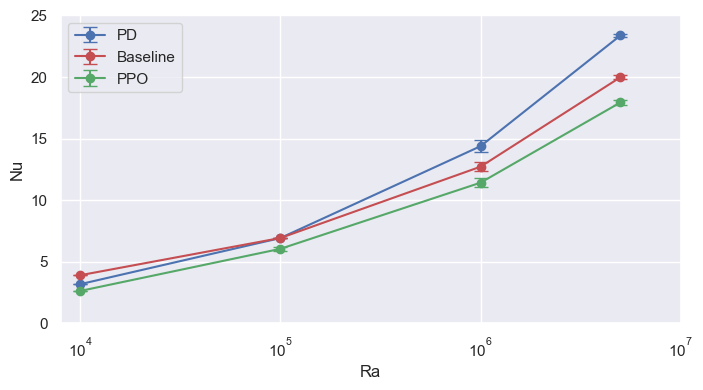

In [25]:

# plot
plt.figure(figsize=(8, 4))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 25)
#plt.yscale("log")
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["pd"], std["pd"], linestyle="-", marker='o', color='b', capsize=5, label="PD")
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["ppo"], std["ppo"], linestyle="-", marker='o', color='g', capsize=5, label="PPO")


plt.legend()
plt.show()

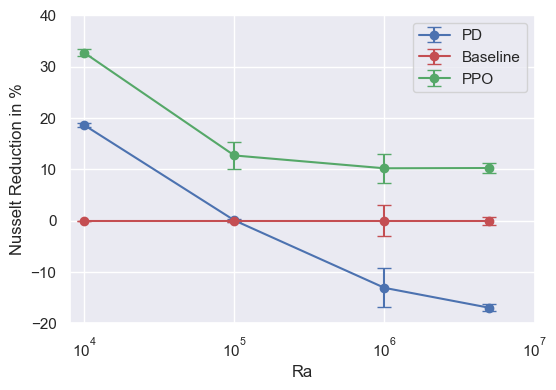

In [20]:
# plot
plt.figure(figsize=(6, 4))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["pd"], std_percent["pd"], linestyle="-", marker='o', capsize=5, label="PD", color=colors[0])
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', capsize=5, label="Baseline", color=colors[3])
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO", color=colors[2])


plt.legend()
plt.savefig("/Users/tmarkmann/Downloads/out.svg")
plt.show()

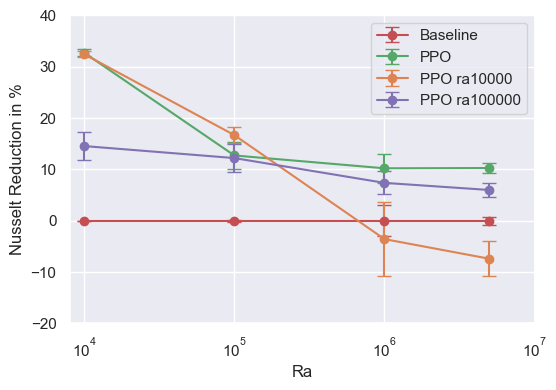

In [24]:
# plot
plt.figure(figsize=(6, 4))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', capsize=5, label="Baseline", color=colors[3])
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO", color=colors[2])
plt.errorbar(ra, mean_percent["ppo_ra10000"], std_percent["ppo_ra10000"], linestyle="-", marker='o', capsize=5, label="PPO ra10000", color=colors[1])
plt.errorbar(ra, mean_percent["ppo_ra100000"], std_percent["ppo_ra100000"], linestyle="-", marker='o', capsize=5, label="PPO ra100000", color=colors[4])


plt.legend()
plt.savefig("/Users/tmarkmann/Downloads/out.svg")
plt.show()

In [15]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]